In [67]:
import copy
import math
import random
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

sys.path.append("/Users/manitej.sriram/Desktop/3rd_year/Sem2/Topics in RL/Deep_RL_Experiments/RT-PG")
from envs.cartpole import ContinuousCartPoleEnv


class CartPoleWrapper:
    """Wrapper to handle action conversion for ContinuousCartPoleEnv"""
    def __init__(self):
        self.env = ContinuousCartPoleEnv()
        
    def reset(self, seed=None):
        if seed is not None:
            self.env.seed(seed)
        return self.env.reset()
    
    def step(self, action):
        # Convert action to 1D numpy array if it's a scalar
        if isinstance(action, (int, float)):
            action = np.array([action], dtype=np.float32)
        elif isinstance(action, np.ndarray) and action.ndim == 0:
            action = np.array([float(action)], dtype=np.float32)
        
        # Verify action is valid
        assert self.env.action_space.contains(action), \
            "%r (%s) invalid" % (action, type(action))
        
        # Extract scalar and convert to float for the environment
        force = self.env.force_mag * float(action.item() if action.size == 1 else action[0])
        
        # Call the environment's physics directly instead of step
        self.env.state = self.env.stepPhysics(force)
        x, x_dot, theta, theta_dot = self.env.state
        
        done = x < -self.env.x_threshold \
            or x > self.env.x_threshold \
            or theta < -self.env.theta_threshold_radians \
            or theta > self.env.theta_threshold_radians
        done = bool(done)

        if not done:
            reward = 1.0
        elif self.env.steps_beyond_done is None:
            self.env.steps_beyond_done = 0
            reward = 1.0
        else:
            if self.env.steps_beyond_done == 0:
                reward = 1.0
            self.env.steps_beyond_done += 1
            reward = 0.0

        return np.array(self.env.state, dtype=np.float32), reward, done, False, {}
    
    @property
    def action_space(self):
        return self.env.action_space
    
    @property
    def observation_space(self):
        return self.env.observation_space
    
    def close(self):
        return self.env.close()

    def seed(self, seed=None):
        return self.env.seed(seed)


@dataclass
class Config:
    seed: int = 7
    horizon: int = 200
    num_iterations: int = 20
    d_k_size: int = 8
    d_k_prime_size: int = 8
    a: float = 1.0
    b: float = 0.2
    c: float = 0.8
    a_prime: float = 1.0
    b_prime: float = 0.2
    c_prime: float = 0.8
    lambda_pg: float = 0.2
    model_hidden_sizes: tuple[int, ...] = (128, 128)
    policy_hidden_sizes: tuple[int, ...] = (128, 128)
    model_lr: float = 1e-3
    policy_lr: float = 3e-4
    model_epochs_per_iter: int = 8
    policy_epochs_per_iter: int = 1
    model_batch_size: int = 64
    policy_batch_size: int = 32
    eval_episodes: int = 5
    reward_scale: float = 1.0
    grad_clip: float = 5.0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CFG = Config()
assert abs(CFG.b + CFG.c - 1.0) < 1e-8
assert abs(CFG.b_prime + CFG.c_prime - 1.0) < 1e-8


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


set_seed(CFG.seed)
print("device:", CFG.device)
print("torch:", torch.__version__)
env = CartPoleWrapper()
obs = env.reset()
env.close()
print("cartpole observation shape:", obs.shape)


device: cpu
torch: 2.11.0
cartpole observation shape: (4,)


/Users/manitej.sriram/Desktop/3rd_year/Sem2/Topics in RL/Deep_RL_Experiments/.venv/lib/python3.14/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [68]:
def to_tensor(array, device=CFG.device, dtype=torch.float32):
    return torch.as_tensor(array, dtype=dtype, device=device)


def as_numpy(tensor):
    if isinstance(tensor, torch.Tensor):
        return tensor.detach().cpu().numpy()
    return np.asarray(tensor)


class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_sizes, activation=nn.Tanh):
        super().__init__()
        layers = []
        last_dim = input_dim
        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(last_dim, hidden_dim))
            layers.append(activation())
            last_dim = hidden_dim
        layers.append(nn.Linear(last_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class GaussianPolicy(nn.Module):
    def __init__(self, state_dim, hidden_sizes, action_dim=1):
        super().__init__()
        self.action_dim = action_dim
        self.mean_net = MLP(state_dim, action_dim, hidden_sizes, activation=nn.Tanh)
        self.log_std = nn.Parameter(torch.full((action_dim,), -0.5))

    def distribution(self, states):
        mean = self.mean_net(states)
        log_std = torch.clamp(self.log_std, -5.0, 2.0)
        std = torch.exp(log_std).expand_as(mean)
        return mean, std

    def sample_action(self, state, deterministic=False):
        state_tensor = to_tensor(state).view(1, -1)
        mean, std = self.distribution(state_tensor)
        if deterministic:
            raw_action = mean
        else:
            raw_action = mean + std * torch.randn_like(mean)
        log_prob = self.log_prob(state_tensor, raw_action)
        continuous_action = torch.clamp(raw_action, -1.0, 1.0)
        return continuous_action.squeeze(0), continuous_action.squeeze(0), log_prob.squeeze(0)

    def log_prob(self, states, actions):
        if states.dim() == 1:
            states = states.unsqueeze(0)
        if actions.dim() == 1:
            actions = actions.unsqueeze(0)
        mean, std = self.distribution(states)
        var = std.pow(2)
        log_scale = torch.log(std)
        return -0.5 * (((actions - mean) ** 2) / var + 2.0 * log_scale + math.log(2.0 * math.pi)).sum(dim=-1)

    def copy(self):
        cloned = GaussianPolicy(
            state_dim=self.mean_net.net[0].in_features,
            hidden_sizes=tuple(layer.out_features for layer in self.mean_net.net if isinstance(layer, nn.Linear))[:-1],
            action_dim=self.action_dim,
        )
        cloned.load_state_dict(copy.deepcopy(self.state_dict()))
        cloned.to(next(self.parameters()).device)
        return cloned


class TransitionModel(nn.Module):
    """Predicts next state and done from state-action pairs"""
    def __init__(self, state_dim, hidden_sizes):
        super().__init__()
        self.state_dim = state_dim
        self.backbone = MLP(state_dim + 1, hidden_sizes[-1] if hidden_sizes else 64, hidden_sizes[:-1], activation=nn.ReLU)
        last_dim = hidden_sizes[-1] if hidden_sizes else 64
        self.next_state_head = nn.Linear(last_dim, state_dim)
        self.done_head = nn.Linear(last_dim, 1)

    def forward(self, states, actions):
        if states.dim() == 1:
            states = states.unsqueeze(0)
        if actions.dim() == 1:
            actions = actions.unsqueeze(-1)
        x = torch.cat([states, actions], dim=-1)
        hidden = self.backbone(x)
        next_state = self.next_state_head(hidden)
        done_logit = self.done_head(hidden).squeeze(-1)
        return next_state, done_logit


class RewardModel(nn.Module):
    """Simple reward model - for CartPole reward is deterministic (0 or 1)"""
    def __init__(self, state_dim):
        super().__init__()
        # Simple architecture: input → hidden → reward
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, states, actions):
        if states.dim() == 1:
            states = states.unsqueeze(0)
        if actions.dim() == 1:
            actions = actions.unsqueeze(-1)
        x = torch.cat([states, actions], dim=-1)
        reward = self.net(x).squeeze(-1)
        return reward


def create_policy(state_dim):
    return GaussianPolicy(state_dim, CFG.policy_hidden_sizes).to(CFG.device)


def create_transition_model(state_dim):
    return TransitionModel(state_dim, CFG.model_hidden_sizes).to(CFG.device)


def create_reward_model(state_dim):
    return RewardModel(state_dim).to(CFG.device)


def trajectory_copy(trajectory):
    return copy.deepcopy(trajectory)


def make_trajectory_record(source, states, actions, rewards, next_states, dones, behavior_log_prob_tau=None, behavior_prob_tau=None, source_iteration=None, policy_index=None, meta=None):
    return {
        "source": source,
        "states": np.asarray(states, dtype=np.float32),
        "actions": np.asarray(actions, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "next_states": np.asarray(next_states, dtype=np.float32),
        "dones": np.asarray(dones, dtype=np.float32),
        "behavior_log_prob_tau": behavior_log_prob_tau,
        "behavior_prob_tau": behavior_prob_tau,
        "source_iteration": source_iteration,
        "policy_index": policy_index,
        "meta": {} if meta is None else dict(meta),
    }


In [72]:
def trajectory_return(trajectory):
    return float(np.sum(trajectory["rewards"]))


def trajectory_return_to_go(rewards):
    returns = np.zeros_like(rewards, dtype=np.float32)
    running = 0.0
    for index in range(len(rewards) - 1, -1, -1):
        running += float(rewards[index])
        returns[index] = running
    return returns


def behavior_policy_mass_on_trajectory(policy, states, actions):
    if len(states) == 0:
        return 0.0, 1.0

    states_tensor = to_tensor(np.asarray(states, dtype=np.float32))
    actions_tensor = to_tensor(np.asarray(actions, dtype=np.float32))
    with torch.no_grad():
        log_prob_tau = float(policy.log_prob(states_tensor, actions_tensor).sum().item())

    prob_tau = float(np.exp(np.clip(log_prob_tau, -80.0, 80.0)))
    return log_prob_tau, prob_tau


def collect_env_trajectory(env, policy, horizon, deterministic=False, source="env", source_iteration=None):
    state = env.reset()
    states, actions, rewards, next_states, dones = [], [], [], [], []

    for _ in range(horizon):
        action_tensor, continuous_action, _ = policy.sample_action(state, deterministic=deterministic)
        action_array = np.array([continuous_action.item()], dtype=np.float32)
        next_state, reward, terminated, truncated, _ = env.step(action_array)
        done = float(terminated or truncated)

        states.append(np.asarray(state, dtype=np.float32))
        actions.append(as_numpy(continuous_action).reshape(-1).astype(np.float32))
        rewards.append(float(reward) * CFG.reward_scale)
        next_states.append(np.asarray(next_state, dtype=np.float32))
        dones.append(done)
        state = next_state
        if done:
            break

    behavior_log_prob_tau, behavior_prob_tau = behavior_policy_mass_on_trajectory(policy, states, actions)

    return make_trajectory_record(
        source=source,
        states=states,
        actions=actions,
        rewards=rewards,
        next_states=next_states,
        dones=dones,
        behavior_log_prob_tau=behavior_log_prob_tau,
        behavior_prob_tau=behavior_prob_tau,
        source_iteration=source_iteration,
        policy_index=source_iteration,
        meta={"kind": "environment"},
    )


def collect_model_trajectory(env, transition_model, reward_model, policy, horizon, deterministic=False, source_iteration=None):
    state = env.reset()
    states, actions, rewards, next_states, dones = [], [], [], [], []

    for _ in range(horizon):
        action_tensor, continuous_action, _ = policy.sample_action(state, deterministic=deterministic)
        state_tensor = to_tensor(state).view(1, -1)
        action_tensor_for_model = to_tensor(as_numpy(continuous_action).reshape(1, -1))

        with torch.no_grad():
            next_state_pred, done_logit = transition_model(state_tensor, action_tensor_for_model)
            reward_pred = reward_model(state_tensor, action_tensor_for_model)
            next_state = as_numpy(next_state_pred.squeeze(0))
            reward = float(reward_pred.squeeze(0).item())
            done_prob = torch.sigmoid(done_logit.squeeze(0)).item()
            done = float(done_prob > 0.5)

        states.append(np.asarray(state, dtype=np.float32))
        actions.append(as_numpy(continuous_action).reshape(-1).astype(np.float32))
        rewards.append(reward)
        next_states.append(np.asarray(next_state, dtype=np.float32))
        dones.append(done)
        state = next_state
        if done:
            break

    behavior_log_prob_tau, behavior_prob_tau = behavior_policy_mass_on_trajectory(policy, states, actions)

    return make_trajectory_record(
        source="model",
        states=states,
        actions=actions,
        rewards=rewards,
        next_states=next_states,
        dones=dones,
        behavior_log_prob_tau=behavior_log_prob_tau,
        behavior_prob_tau=behavior_prob_tau,
        source_iteration=source_iteration,
        policy_index=source_iteration,
        meta={"kind": "empirical_model"},
    )


def sample_trajectory(dataset):
    if not dataset:
        return None
    return trajectory_copy(random.choice(dataset))


def generate_mixed_dataset(env, policy, transition_model, reward_model, horizon, num_trajectories, env_prob, model_prob, replay_prob, previous_dataset, source_iteration=None):
    assert abs(env_prob + model_prob + replay_prob - 1.0) < 1e-8
    dataset = []

    for _ in range(num_trajectories):
        draw = random.random()
        if previous_dataset is None or len(previous_dataset) == 0 or draw < env_prob:
            trajectory = collect_env_trajectory(env, policy, horizon, deterministic=False, source_iteration=source_iteration)
        elif draw < env_prob + model_prob:
            if transition_model is None or reward_model is None:
                trajectory = collect_env_trajectory(env, policy, horizon, deterministic=False, source_iteration=source_iteration)
            else:
                trajectory = collect_model_trajectory(env, transition_model, reward_model, policy, horizon, deterministic=False, source_iteration=source_iteration)
        else:
            trajectory = sample_trajectory(previous_dataset)
            if trajectory is None:
                trajectory = collect_env_trajectory(env, policy, horizon, deterministic=False, source_iteration=source_iteration)
        dataset.append(trajectory)

    return dataset


def flatten_transitions(dataset):
    states, actions, next_states, rewards, dones = [], [], [], [], []
    for trajectory in dataset:
        states.extend(trajectory["states"])
        actions.extend(trajectory["actions"])
        next_states.extend(trajectory["next_states"])
        rewards.extend(trajectory["rewards"])
        dones.extend(trajectory["dones"])
    if not states:
        return None
    return {
        "states": np.asarray(states, dtype=np.float32),
        "actions": np.asarray(actions, dtype=np.float32).reshape(-1, 1),
        "next_states": np.asarray(next_states, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=np.float32),
    }


def train_dynamics_models(transition_model, reward_model, transition_optimizer, reward_optimizer, dataset, epochs, batch_size):
    transition_data = flatten_transitions(dataset)
    if transition_data is None:
        return 0.0

    states = to_tensor(transition_data["states"])
    actions = to_tensor(transition_data["actions"])
    next_states = to_tensor(transition_data["next_states"])
    rewards = to_tensor(transition_data["rewards"])
    dones = to_tensor(transition_data["dones"])

    transition_model.train()
    reward_model.train()
    total_loss = 0.0
    num_samples = states.shape[0]

    for _ in range(epochs):
        permutation = torch.randperm(num_samples, device=CFG.device)
        for start in range(0, num_samples, batch_size):
            indices = permutation[start:start + batch_size]
            batch_states = states[indices]
            batch_actions = actions[indices]
            batch_next_states = next_states[indices]
            batch_rewards = rewards[indices]
            batch_dones = dones[indices]

            # Train transition model (next_state and done)
            predicted_next_states, predicted_done_logits = transition_model(batch_states, batch_actions)
            loss_next = F.mse_loss(predicted_next_states, batch_next_states)
            loss_done = F.binary_cross_entropy_with_logits(predicted_done_logits, batch_dones)
            loss_transition = loss_next + loss_done

            transition_optimizer.zero_grad(set_to_none=True)
            loss_transition.backward()
            torch.nn.utils.clip_grad_norm_(transition_model.parameters(), CFG.grad_clip)
            transition_optimizer.step()

            # Train reward model
            predicted_rewards = reward_model(batch_states, batch_actions)
            loss_reward = F.mse_loss(predicted_rewards, batch_rewards)

            reward_optimizer.zero_grad(set_to_none=True)
            loss_reward.backward()
            torch.nn.utils.clip_grad_norm_(reward_model.parameters(), CFG.grad_clip)
            reward_optimizer.step()

            total_loss += float((loss_transition + loss_reward).item())

    return total_loss / max(1, epochs * math.ceil(num_samples / batch_size))


def log_importance_ratio(trajectory, current_policy):
    behavior_log_prob_tau = trajectory.get("behavior_log_prob_tau")
    if behavior_log_prob_tau is None:
        return 1.0

    current_policy.eval()

    states = to_tensor(trajectory["states"])
    actions = to_tensor(trajectory["actions"])

    with torch.no_grad():
        current_log_prob = current_policy.log_prob(states, actions).sum()
        log_ratio = torch.clamp(current_log_prob - float(behavior_log_prob_tau), -20.0, 20.0)
    return float(torch.exp(log_ratio).item())


def evaluate_policy(env, policy, episodes, horizon):
    returns = []
    policy.eval()
    with torch.no_grad():
        for _ in range(episodes):
            state = env.reset()
            episode_return = 0.0
            for _ in range(horizon):
                _, continuous_action, _ = policy.sample_action(state, deterministic=False)
                action_array = np.array([continuous_action.item()], dtype=np.float32)
                next_state, reward, terminated, truncated, _ = env.step(action_array)
                episode_return += float(reward)
                state = next_state
                if terminated or truncated:
                    break
            returns.append(episode_return)
    policy.train()
    return float(np.mean(returns)), returns


In [70]:
def compute_g_theta(policy, trajectory):
    states = to_tensor(trajectory["states"])
    actions = to_tensor(trajectory["actions"])
    returns_to_go = to_tensor(trajectory_return_to_go(trajectory["rewards"]))
    log_probs = policy.log_prob(states, actions)
    return torch.sum(returns_to_go * log_probs)


def compute_policy_loss(policy_history, policy, iteration_k, lambda_pg):
    total_objective = torch.zeros((), device=CFG.device)
    diagnostics = []

    alpha_k = 1.0 / max(1, iteration_k)
    lambda_k = float(lambda_pg)
    
    for dataset_index, dataset in enumerate(policy_history, start=1):
        if not dataset:
            continue

        trajectories_by_policy = {}
        for trajectory in dataset:
            policy_index = trajectory.get("policy_index")
            if policy_index is None:
                continue
            trajectories_by_policy.setdefault(policy_index, []).append(trajectory)

        dataset_objective = torch.zeros((), device=CFG.device)
        grouped_counts = {policy_index: len(trajectories) for policy_index, trajectories in trajectories_by_policy.items()}
        for policy_index, trajectories in trajectories_by_policy.items():
            N_i = grouped_counts[policy_index]
            policy_group_objective = torch.zeros((), device=CFG.device)
            for trajectory in trajectories:
                g_theta = compute_g_theta(policy, trajectory)
                states = to_tensor(trajectory["states"])
                actions = to_tensor(trajectory["actions"])
                behavior_log_prob_tau = float(trajectory["behavior_log_prob_tau"])
                current_log_prob_tau = policy.log_prob(states, actions).sum()
                ratio = torch.exp(torch.clamp(behavior_log_prob_tau - current_log_prob_tau, -20.0, 20.0))
                denominator = (1.0 - lambda_k) * ratio.detach() + lambda_k
                policy_group_objective = policy_group_objective + g_theta / denominator
            dataset_objective = dataset_objective + (alpha_k / N_i) * policy_group_objective

        total_objective = total_objective + dataset_objective
        diagnostics.append({
            "dataset_index": dataset_index,
            "dataset_size": len(dataset),
            "dataset_objective": float(dataset_objective.detach().item()),
        })

    return total_objective, diagnostics


def run_experiment(cfg=CFG):
    set_seed(cfg.seed)
    env = CartPoleWrapper()
    env.seed(cfg.seed)
    state_dim = env.observation_space.shape[0]
    policy = create_policy(state_dim)
    transition_model = create_transition_model(state_dim)
    reward_model = create_reward_model(state_dim)
    transition_optimizer = torch.optim.Adam(transition_model.parameters(), lr=cfg.model_lr)
    reward_optimizer = torch.optim.Adam(reward_model.parameters(), lr=cfg.model_lr)
    bootstrap_count = max(cfg.d_k_size, cfg.d_k_prime_size)
    bootstrap_dataset = [
        collect_env_trajectory(env, policy, cfg.horizon, deterministic=False, source="env", source_iteration=0)
        for _ in range(bootstrap_count)
    ]

    model_memory = list(bootstrap_dataset)
    previous_dk = list(bootstrap_dataset)
    previous_dprime = list(bootstrap_dataset)
    policy_history = []

    model_loss_history = []
    policy_loss_history = []
    evaluation_return_history = []
    evaluation_episode_returns = []
    iteration_history = []

    initial_model_loss = train_dynamics_models(
        transition_model,
        reward_model,
        transition_optimizer,
        reward_optimizer,
        model_memory,
        epochs=max(1, cfg.model_epochs_per_iter),
        batch_size=cfg.model_batch_size,
    )
    model_loss_history.append(initial_model_loss)

    for iteration_k in range(1, cfg.num_iterations + 1):
        d_k = generate_mixed_dataset(
            env=env,
            policy=policy,
            transition_model=transition_model,
            reward_model=reward_model,
            horizon=cfg.horizon,
            num_trajectories=cfg.d_k_size,
            env_prob=cfg.a,
            model_prob=(1.0 - cfg.a) * cfg.b,
            replay_prob=(1.0 - cfg.a) * cfg.c,
            previous_dataset=previous_dk,
            source_iteration=iteration_k,
        )
        model_memory.extend(d_k)
        model_loss = train_dynamics_models(
            transition_model,
            reward_model,
            transition_optimizer,
            reward_optimizer,
            model_memory,
            epochs=cfg.model_epochs_per_iter,
            batch_size=cfg.model_batch_size,
        )
        model_loss_history.append(model_loss)

        d_prime = generate_mixed_dataset(
            env=env,
            policy=policy,
            transition_model=transition_model,
            reward_model=reward_model,
            horizon=cfg.horizon,
            num_trajectories=cfg.d_k_prime_size,
            env_prob=cfg.a_prime,
            model_prob=(1.0 - cfg.a_prime) * cfg.b_prime,
            replay_prob=(1.0 - cfg.a_prime) * cfg.c_prime,
            previous_dataset=previous_dprime,
            source_iteration=iteration_k,
        )
        policy_history.append(d_prime)
        previous_dk = d_k
        previous_dprime = d_prime

        policy.train()
        policy_loss_value = 0.0
        for _ in range(cfg.policy_epochs_per_iter):
            for parameter in policy.parameters():
                parameter.grad = None
            policy_objective, diagnostics = compute_policy_loss(policy_history, policy, iteration_k, cfg.lambda_pg)
            policy_loss = -policy_objective
            policy_loss.backward()
            with torch.no_grad():
                for parameter in policy.parameters():
                    if parameter.grad is None:
                        continue
                    parameter.add_(cfg.policy_lr * parameter.grad)
                    parameter.grad = None
            policy_loss_value = float(policy_objective.detach().item())

        avg_return, episode_returns = evaluate_policy(env, policy, cfg.eval_episodes, cfg.horizon)
        evaluation_return_history.append(avg_return)
        evaluation_episode_returns.append(episode_returns)
        policy_loss_history.append(policy_loss_value)
        iteration_history.append(iteration_k)

        print(
            f"iter={iteration_k:03d} | model_loss={model_loss:.4f} | policy_objective={policy_loss_value:.4f} | avg_return={avg_return:.2f}"
        )

    env.close()
    return {
        "policy": policy,
        "transition_model": transition_model,
        "reward_model": reward_model,
        "iterations": iteration_history,
        "model_loss_history": model_loss_history,
        "policy_loss_history": policy_loss_history,
        "evaluation_return_history": evaluation_return_history,
        "evaluation_episode_returns": evaluation_episode_returns,
        "policy_history": policy_history,
        "bootstrap_dataset": bootstrap_dataset,
        "model_memory": model_memory,
    }


def plot_learning_curve(results):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(results["iterations"], results["evaluation_return_history"], marker="o", linewidth=2)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Average Return")
    ax.set_title("CartPole Policy Gradient with Empirical Model Reuse")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax


iter=001 | model_loss=1.1709 | policy_objective=-99.0647 | avg_return=13.50
iter=002 | model_loss=0.8207 | policy_objective=-94.3082 | avg_return=19.50
iter=003 | model_loss=0.5759 | policy_objective=-91.7332 | avg_return=9.50
iter=004 | model_loss=0.3894 | policy_objective=-85.9314 | avg_return=16.00
iter=005 | model_loss=0.2827 | policy_objective=-80.9642 | avg_return=13.50
iter=006 | model_loss=0.2353 | policy_objective=-62.5893 | avg_return=12.00
iter=007 | model_loss=0.2038 | policy_objective=-55.9941 | avg_return=10.00
iter=008 | model_loss=0.1792 | policy_objective=-47.1128 | avg_return=8.50
iter=009 | model_loss=0.1623 | policy_objective=-38.7463 | avg_return=12.00
iter=010 | model_loss=0.1494 | policy_objective=-34.6893 | avg_return=8.50
iter=011 | model_loss=0.1381 | policy_objective=-31.6730 | avg_return=10.00
iter=012 | model_loss=0.1319 | policy_objective=-27.2724 | avg_return=13.00
iter=013 | model_loss=0.1184 | policy_objective=-23.7837 | avg_return=10.00
iter=014 | mode

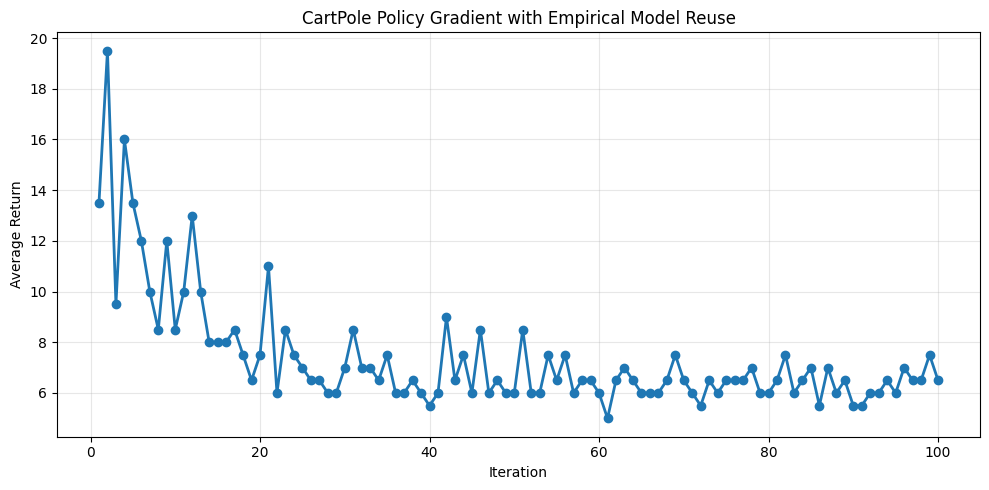

final average return: 6.5
all returns: [13.5, 19.5, 9.5, 16.0, 13.5, 12.0, 10.0, 8.5, 12.0, 8.5, 10.0, 13.0, 10.0, 8.0, 8.0, 8.0, 8.5, 7.5, 6.5, 7.5, 11.0, 6.0, 8.5, 7.5, 7.0, 6.5, 6.5, 6.0, 6.0, 7.0, 8.5, 7.0, 7.0, 6.5, 7.5, 6.0, 6.0, 6.5, 6.0, 5.5, 6.0, 9.0, 6.5, 7.5, 6.0, 8.5, 6.0, 6.5, 6.0, 6.0, 8.5, 6.0, 6.0, 7.5, 6.5, 7.5, 6.0, 6.5, 6.5, 6.0, 5.0, 6.5, 7.0, 6.5, 6.0, 6.0, 6.0, 6.5, 7.5, 6.5, 6.0, 5.5, 6.5, 6.0, 6.5, 6.5, 6.5, 7.0, 6.0, 6.0, 6.5, 7.5, 6.0, 6.5, 7.0, 5.5, 7.0, 6.0, 6.5, 5.5, 5.5, 6.0, 6.0, 6.5, 6.0, 7.0, 6.5, 6.5, 7.5, 6.5]


In [74]:
RUN_DEMO = True

if RUN_DEMO:
    demo_cfg = Config(
        **{
            **CFG.__dict__,
            "num_iterations": 100,
            "d_k_size": 20,
            "d_k_prime_size": 20,
            "model_epochs_per_iter": 1,
            "policy_epochs_per_iter": 1,
            "eval_episodes": 2,
            "seed": 7,
        }
    )
    results = run_experiment(demo_cfg)
    plot_learning_curve(results)
    plt.show()
    print("final average return:", results["evaluation_return_history"][-1])
    print("all returns:", results["evaluation_return_history"])
